# Delinquency Prediction – Model Comparison

Compare five classifiers on the **top-50 selected features** from the feature selection pipeline:

| Model | Library |
|---|---|
| Logistic Regression | scikit-learn |
| XGBoost | xgboost |
| LightGBM | lightgbm |
| Random Forest | scikit-learn |
| Gradient Boosting | scikit-learn |

**Metric:** ROC-AUC on Train / Validation / Test  
**Split:** 60 / 20 / 20  (stratified)

## 1. Import Required Libraries

In [135]:
import sys
import importlib
import pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

# XGBoost
import xgboost as xgb

# LightGBM
import lightgbm as lgb

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data loading helper — reload to pick up any recent changes
import scripts.model_data as _md
importlib.reload(_md)
from scripts.model_data import load_and_split

## 2. Load Data (Top-50 Features, 60/20/20 Split)

In [136]:
N_FEATURES    = 125
FEATURES_FILE = "filtered_features_consensus_ordered.csv" 

X_train, X_val, X_test, y_train, y_val, y_test, feature_names, features_df = \
    load_and_split(n_features=N_FEATURES, features_filename=FEATURES_FILE)

print(f'\nFeatures used : {len(feature_names)}')
print(f'Train         : {X_train.shape}  | positives: {y_train.sum()} ({100*y_train.mean():.1f}%)')
print(f'Validation    : {X_val.shape}  | positives: {y_val.sum()} ({100*y_val.mean():.1f}%)')
print(f'Test          : {X_test.shape}  | positives: {y_test.sum()} ({100*y_test.mean():.1f}%)')

Features  : 125 (top-125)
Samples   : 10754  |  DQ rate: 8.18%
Train     : 6452  (8.18% positive)
Val       : 2151  (8.18% positive)
Test      : 2151  (8.18% positive)

Features used : 125
Train         : (6452, 125)  | positives: 528 (8.2%)
Validation    : (2151, 125)  | positives: 176 (8.2%)
Test          : (2151, 125)  | positives: 176 (8.2%)


## 3. Shared Preprocessing

Scale features once (fit on train only). Tree-based models will use the raw arrays; 
Logistic Regression and the RNN will use the scaled versions.

In [137]:
# Standard scaling (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Class imbalance weights
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos          # for XGBoost / LightGBM
print(f'Negative: {neg}  |  Positive: {pos}  |  scale_pos_weight: {scale_pos_weight:.2f}')

# Storage for results
results = {}   # {model_name: {'train': auc, 'val': auc, 'test': auc}}
test_probs = {}  # {model_name: np.array} – for ROC curve plot

Negative: 5924  |  Positive: 528  |  scale_pos_weight: 11.22


## 4. Logistic Regression

In [138]:
t0 = time.time()

lr = LogisticRegression(
    C=0.1,
    penalty='l2',
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
)
lr.fit(X_train_sc, y_train)

train_time_lr = time.time() - t0

auc_train = roc_auc_score(y_train, lr.predict_proba(X_train_sc)[:, 1])
auc_val   = roc_auc_score(y_val,   lr.predict_proba(X_val_sc)[:, 1])
auc_test  = roc_auc_score(y_test,  lr.predict_proba(X_test_sc)[:, 1])

results['Logistic Regression'] = {'train': auc_train, 'val': auc_val, 'test': auc_test}
test_probs['Logistic Regression'] = lr.predict_proba(X_test_sc)[:, 1]

print(f'Logistic Regression  (train time: {train_time_lr:.1f}s)')
print(f'  Train AUC : {auc_train:.4f}')
print(f'  Val   AUC : {auc_val:.4f}')
print(f'  Test  AUC : {auc_test:.4f}')

Logistic Regression  (train time: 0.0s)
  Train AUC : 0.7946
  Val   AUC : 0.7401
  Test  AUC : 0.7525


## 5. XGBoost

In [139]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 4,
    'min_child_weight': 15,
    'gamma': 2.3224816595124826,
    'reg_alpha': 8.16755007065582,
    'reg_lambda': 6.255697109863585,
    'eta': 0.09052651425979183,
    'subsample': 0.659046505317891,
    'colsample_bytree': 0.46118195877747536,
    'scale_pos_weight': scale_pos_weight,
    'seed': 42,
    'verbosity': 0,
}

evals_result = {}
t0 = time.time()
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=30,
    evals_result=evals_result,
    verbose_eval=False,
)
train_time_xgb = time.time() - t0

auc_train = roc_auc_score(y_train, xgb_model.predict(dtrain))
auc_val   = roc_auc_score(y_val,   xgb_model.predict(dval))
auc_test  = roc_auc_score(y_test,  xgb_model.predict(dtest))

results['XGBoost'] = {'train': auc_train, 'val': auc_val, 'test': auc_test}
test_probs['XGBoost'] = xgb_model.predict(dtest)

print(f'XGBoost  (best iteration: {xgb_model.best_iteration}, train time: {train_time_xgb:.1f}s)')
print(f'  Train AUC : {auc_train:.4f}')
print(f'  Val   AUC : {auc_val:.4f}')
print(f'  Test  AUC : {auc_test:.4f}')

XGBoost  (best iteration: 106, train time: 0.4s)
  Train AUC : 0.9774
  Val   AUC : 0.7953
  Test  AUC : 0.8061


## 6. LightGBM

In [140]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val,   label=y_val, reference=lgb_train)

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'scale_pos_weight': scale_pos_weight,
    'verbose': -1,
    'seed': 42,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=False),
    lgb.log_evaluation(period=-1),
]

t0 = time.time()
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'val'],
    callbacks=callbacks,
)
train_time_lgb = time.time() - t0

auc_train = roc_auc_score(y_train, lgb_model.predict(X_train))
auc_val   = roc_auc_score(y_val,   lgb_model.predict(X_val))
auc_test  = roc_auc_score(y_test,  lgb_model.predict(X_test))

results['LightGBM'] = {'train': auc_train, 'val': auc_val, 'test': auc_test}
test_probs['LightGBM'] = lgb_model.predict(X_test)

print(f'LightGBM  (best iteration: {lgb_model.best_iteration}, train time: {train_time_lgb:.1f}s)')
print(f'  Train AUC : {auc_train:.4f}')
print(f'  Val   AUC : {auc_val:.4f}')
print(f'  Test  AUC : {auc_test:.4f}')

LightGBM  (best iteration: 6, train time: 0.3s)
  Train AUC : 0.9053
  Val   AUC : 0.7732
  Test  AUC : 0.7637


## 7. Random Forest

In [141]:
from sklearn.ensemble import RandomForestClassifier

t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

train_time_rf = time.time() - t0

auc_train = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
auc_val   = roc_auc_score(y_val,   rf.predict_proba(X_val)[:, 1])
auc_test  = roc_auc_score(y_test,  rf.predict_proba(X_test)[:, 1])

results['Random Forest'] = {'train': auc_train, 'val': auc_val, 'test': auc_test}
test_probs['Random Forest'] = rf.predict_proba(X_test)[:, 1]

print(f'Random Forest  (train time: {train_time_rf:.1f}s)')
print(f'  Train AUC : {auc_train:.4f}')
print(f'  Val   AUC : {auc_val:.4f}')
print(f'  Test  AUC : {auc_test:.4f}')

Random Forest  (train time: 0.6s)
  Train AUC : 0.9943
  Val   AUC : 0.7729
  Test  AUC : 0.8001


## 8. Gradient Boosting

In [142]:
from sklearn.ensemble import GradientBoostingClassifier

t0 = time.time()

gbm = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=50,
    random_state=42,
)
gbm.fit(X_train, y_train)

train_time_gbm = time.time() - t0

auc_train = roc_auc_score(y_train, gbm.predict_proba(X_train)[:, 1])
auc_val   = roc_auc_score(y_val,   gbm.predict_proba(X_val)[:, 1])
auc_test  = roc_auc_score(y_test,  gbm.predict_proba(X_test)[:, 1])

results['Gradient Boosting'] = {'train': auc_train, 'val': auc_val, 'test': auc_test}
test_probs['Gradient Boosting'] = gbm.predict_proba(X_test)[:, 1]

print(f'Gradient Boosting  (train time: {train_time_gbm:.1f}s)')
print(f'  Train AUC : {auc_train:.4f}')
print(f'  Val   AUC : {auc_val:.4f}')
print(f'  Test  AUC : {auc_test:.4f}')

Gradient Boosting  (train time: 36.3s)
  Train AUC : 0.9987
  Val   AUC : 0.7799
  Test  AUC : 0.8129


## 9. ROC-AUC Comparison Table

A gap of **Train AUC − Test AUC** larger than ~0.05 suggests overfitting.

                     Train AUC  Val AUC  Test AUC  Train-Test Gap  Threshold  Accuracy  Precision      F1  Pred Time (ms)
Model                                                                                                                    
Logistic Regression     0.7946   0.7401    0.7525          0.0421     0.4502    0.6653     0.1583  0.2593           0.723
XGBoost                 0.9774   0.7953    0.8061          0.1713     0.3130    0.7215     0.1903  0.3027           0.205
LightGBM                0.9053   0.7732    0.7637          0.1416     0.1621    0.6890     0.1609  0.2591           0.267
Random Forest           0.9943   0.7729    0.8001          0.1942     0.1815    0.6718     0.1696  0.2781          48.748
Gradient Boosting       0.9987   0.7799    0.8129          0.1859     0.0546    0.7987     0.2328  0.3409           9.675


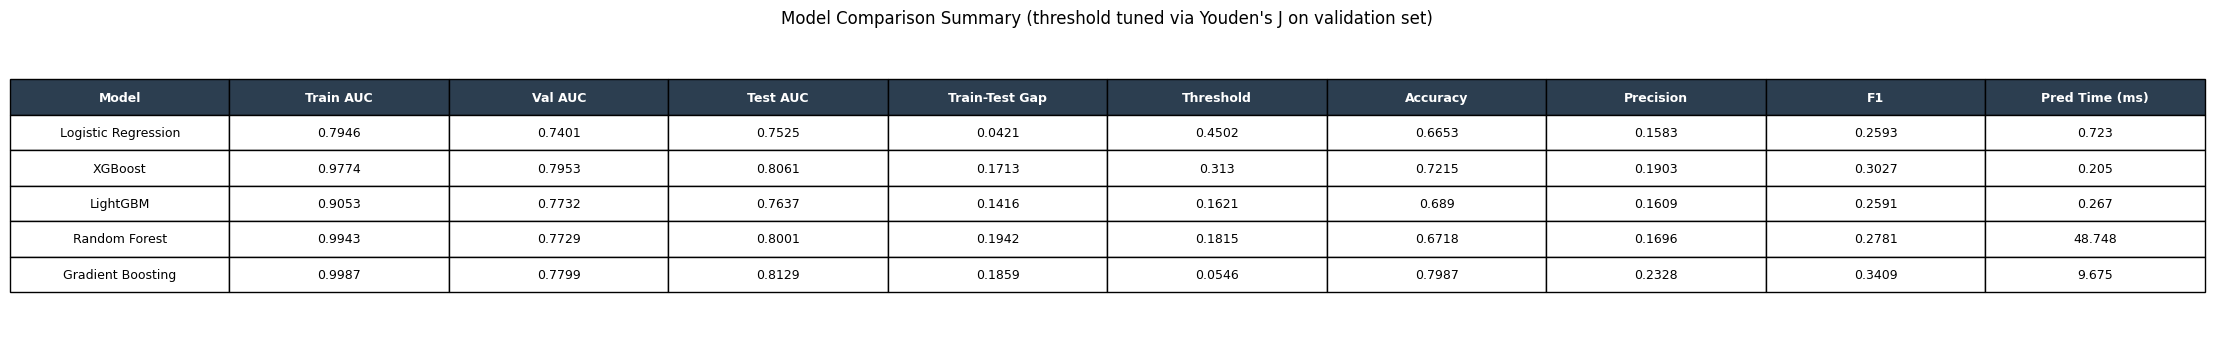

In [148]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

_compare_models = ['Logistic Regression', 'XGBoost', 'LightGBM', 'Random Forest', 'Gradient Boosting']
_compare_results = {k: v for k, v in results.items() if k in _compare_models}

# Build AUC DataFrame
comparison_df = pd.DataFrame(_compare_results, index=['train', 'val', 'test']).T
comparison_df.index.name = 'Model'
comparison_df.columns = ['Train AUC', 'Val AUC', 'Test AUC']
comparison_df['Train-Test Gap'] = (comparison_df['Train AUC'] - comparison_df['Test AUC']).round(4)

# Prediction-time + classification metrics
# Use a per-model threshold tuned on validation set (Youden's J: max TPR - FPR)
predict_fns = {
    'Logistic Regression': lambda: lr.predict_proba(X_test_sc)[:, 1],
    'XGBoost':             lambda: xgb_model.predict(dtest),
    'LightGBM':            lambda: lgb_model.predict(X_test),
    'Random Forest':       lambda: rf.predict_proba(X_test)[:, 1],
    'Gradient Boosting':   lambda: gbm.predict_proba(X_test)[:, 1],
}

val_probs_fns = {
    'Logistic Regression': lambda: lr.predict_proba(X_val_sc)[:, 1],
    'XGBoost':             lambda: xgb_model.predict(dval),
    'LightGBM':            lambda: lgb_model.predict(X_val),
    'Random Forest':       lambda: rf.predict_proba(X_val)[:, 1],
    'Gradient Boosting':   lambda: gbm.predict_proba(X_val)[:, 1],
}

pred_times, accs, precs, recs, f1s, thresholds = [], [], [], [], [], []

N_REPEATS = 20  # repeat predictions to get a stable timing estimate

for m in _compare_models:
    # Find best threshold on validation set via Youden's J statistic
    val_probs = val_probs_fns[m]()
    fpr_v, tpr_v, thresh_v = roc_curve(y_val, val_probs)
    youden_j = tpr_v - fpr_v
    best_thresh = float(thresh_v[np.argmax(youden_j)])
    thresholds.append(round(best_thresh, 4))

    # Time over N_REPEATS using perf_counter (high resolution on all platforms)
    t0 = time.perf_counter()
    for _ in range(N_REPEATS):
        probs = predict_fns[m]()
    elapsed_ms = (time.perf_counter() - t0) * 1000 / N_REPEATS
    pred_times.append(round(elapsed_ms, 3))

    preds = (probs >= best_thresh).astype(int)
    accs.append(round(accuracy_score(y_test, preds), 4))
    precs.append(round(precision_score(y_test, preds, zero_division=0), 4))
    recs.append(round(recall_score(y_test, preds, zero_division=0), 4))
    f1s.append(round(f1_score(y_test, preds, zero_division=0), 4))

comparison_df['Threshold']      = thresholds
comparison_df['Accuracy']       = accs
comparison_df['Precision']      = precs
comparison_df['F1']             = f1s
comparison_df['Pred Time (ms)'] = pred_times

comparison_df[['Train AUC', 'Val AUC', 'Test AUC', 'Train-Test Gap']] = \
    comparison_df[['Train AUC', 'Val AUC', 'Test AUC', 'Train-Test Gap']].round(4)

print('=' * 120)
print(comparison_df.to_string())
print('=' * 120)

# Styled table
fig, ax = plt.subplots(figsize=(22, 3.5))
ax.axis('off')
tbl = ax.table(
    cellText=comparison_df.reset_index().values,
    colLabels=['Model'] + list(comparison_df.columns),
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 2.0)

for j in range(len(comparison_df.columns) + 1):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

plt.title('Model Comparison Summary (threshold tuned via Youden\'s J on validation set)', pad=14, fontsize=12)
plt.tight_layout()
plt.show()



## 10. ROC Curve Visualization (Test Set)

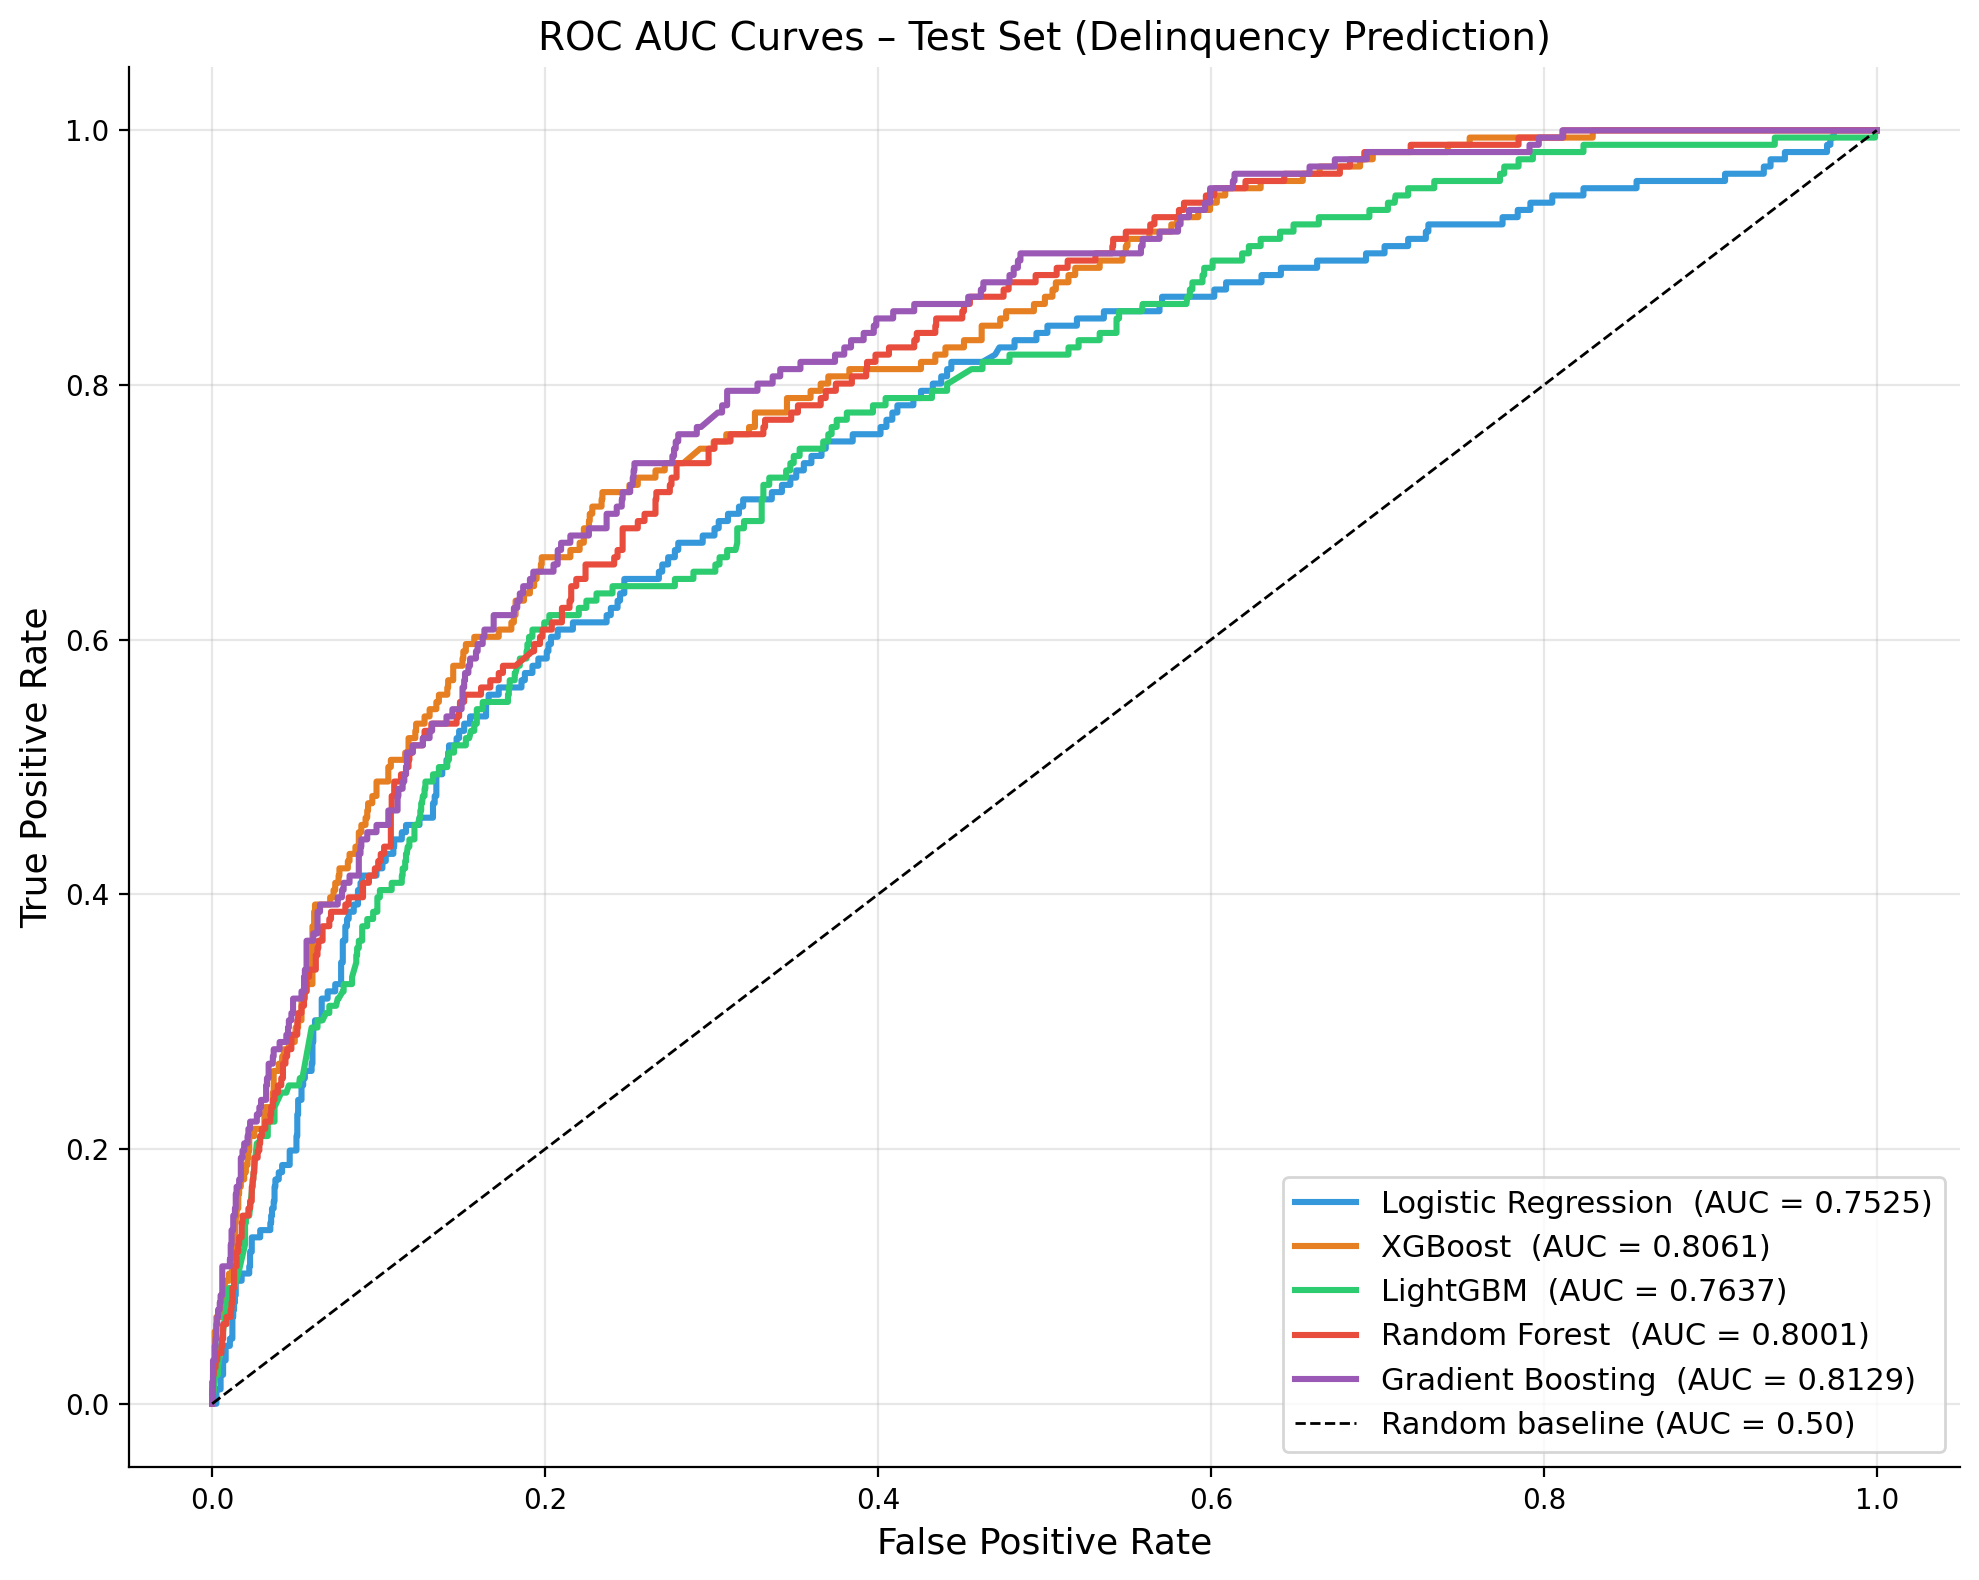

In [144]:
palette = {
    'Logistic Regression': '#3498db',
    'XGBoost':             '#e67e22',
    'LightGBM':            '#2ecc71',
    'Random Forest':       '#e74c3c',
    'Gradient Boosting':   '#9b59b6',
}

_compare_models = ['Logistic Regression', 'XGBoost', 'LightGBM', 'Random Forest', 'Gradient Boosting']

fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

for model_name in _compare_models:
    probs = test_probs[model_name]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = results[model_name]['test']
    ax.plot(fpr, tpr, label=f'{model_name}  (AUC = {auc:.4f})',
            color=palette[model_name], linewidth=2.2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.0, label='Random baseline (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC AUC Curves – Test Set (Delinquency Prediction)', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("roc_auc_hd.png", dpi=200, bbox_inches='tight')
plt.show()


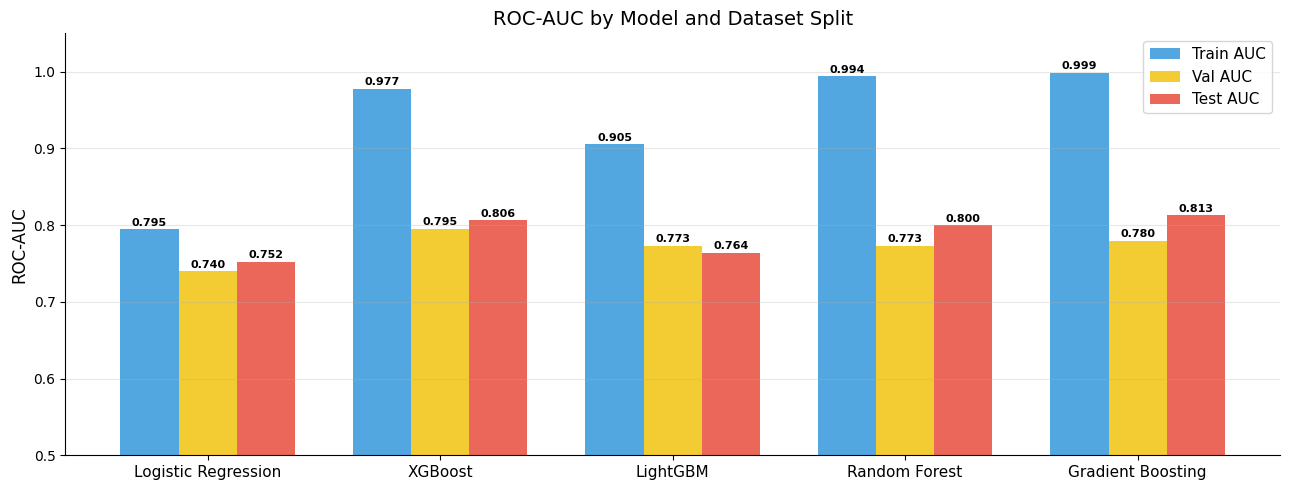

In [145]:
plot_df = comparison_df[['Train AUC', 'Val AUC', 'Test AUC']].reset_index()
plot_df = plot_df.melt(id_vars='Model', var_name='Split', value_name='ROC-AUC')

fig, ax = plt.subplots(figsize=(13, 5))
split_order = ['Train AUC', 'Val AUC', 'Test AUC']
model_order = ['Logistic Regression', 'XGBoost', 'LightGBM', 'Random Forest', 'Gradient Boosting']
x = np.arange(len(model_order))
width = 0.25
colours = ['#3498db', '#f1c40f', '#e74c3c']

for i, split in enumerate(split_order):
    vals = [comparison_df.loc[m, split] for m in model_order]
    bars = ax.bar(x + i * width, vals, width, label=split, color=colours[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(model_order, fontsize=11)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_ylim(0.5, 1.05)
ax.set_title('ROC-AUC by Model and Dataset Split', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

## 11. Confusion Matrices – XGBoost & Gradient Boosting

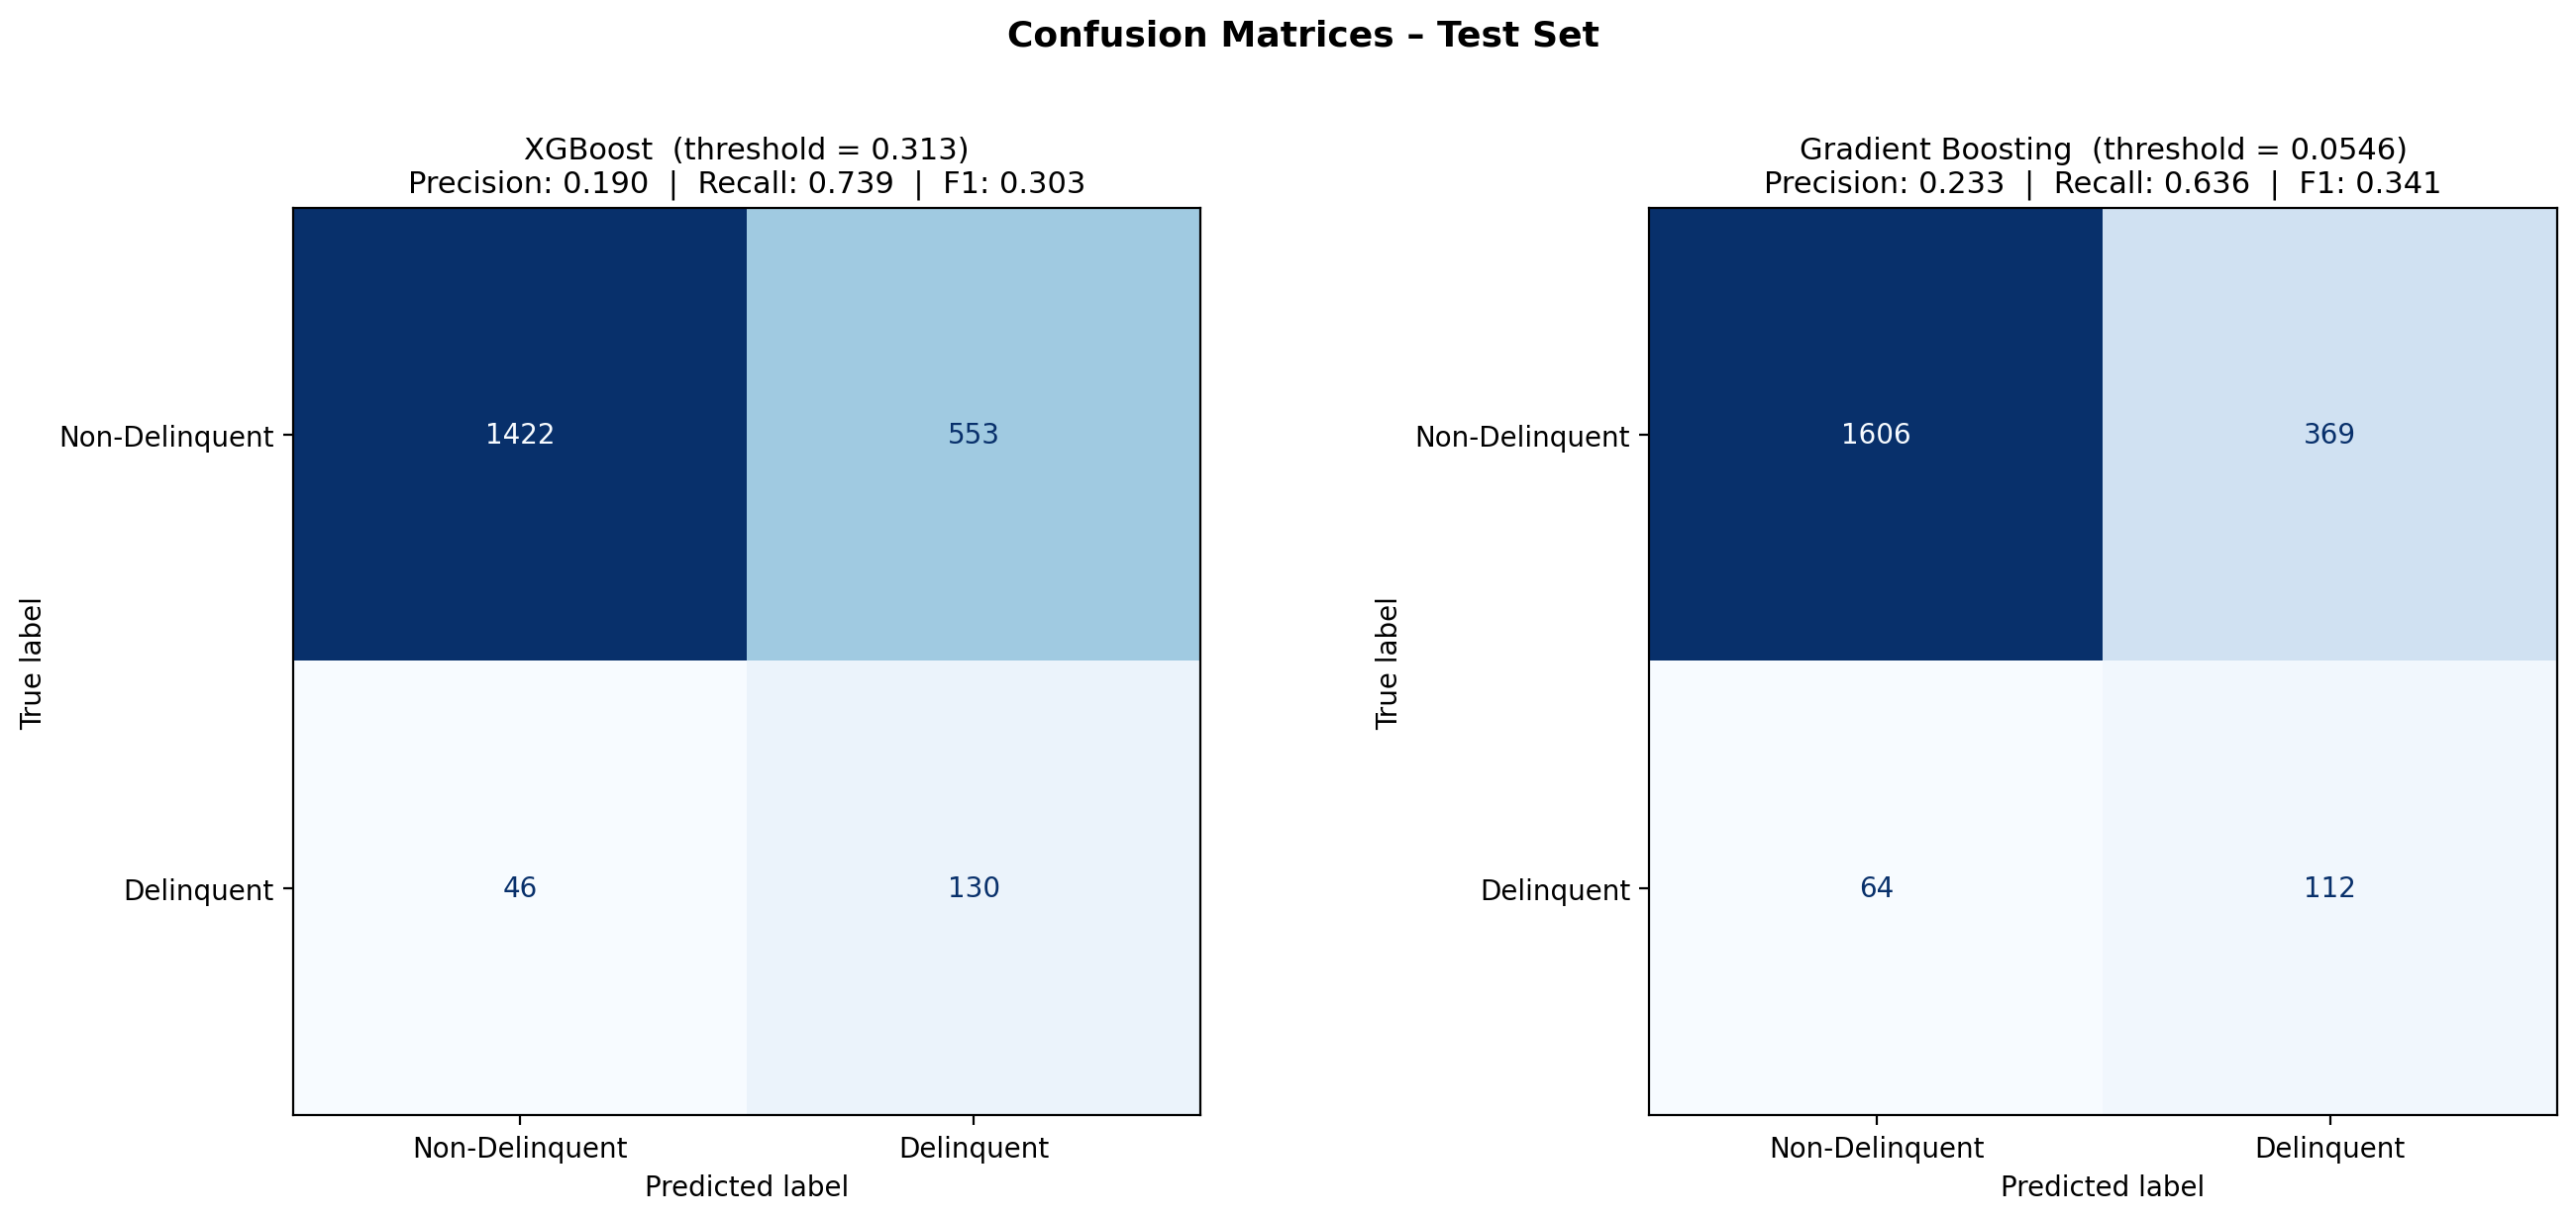

In [149]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_models = {
    'XGBoost':           (xgb_model.predict(dtest),  comparison_df.loc['XGBoost',           'Threshold']),
    'Gradient Boosting': (gbm.predict_proba(X_test)[:, 1], comparison_df.loc['Gradient Boosting', 'Threshold']),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=200)

for ax, (model_name, (probs, thresh)) in zip(axes, cm_models.items()):
    preds = (probs >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Delinquent', 'Delinquent'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    # Annotate with rates
    tn, fp, fn, tp = cm.ravel()
    total = cm.sum()
    ax.set_title(
        f'{model_name}  (threshold = {thresh})\n'
        f'Precision: {tp/(tp+fp):.3f}  |  Recall: {tp/(tp+fn):.3f}  |  '
        f'F1: {2*tp/(2*tp+fp+fn):.3f}',
        fontsize=11
    )

plt.suptitle('Confusion Matrices – Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
